# Fake dataset generation and upper-limits
F. Acero, June 2026.
Simulation of fake datasets to probe the behavior of upper-limit computation gammapy v2.0.1.  
Script accompanying the gammapy v2 paper.

In this script we :  

- Build a fake `SpectrumDatasetOnOff` with CTAO IRFs and pure background for a given exposure time
- Use `FluxPointsEstimator` to derive upper-limits+sensitivity using the profile likelihood (frequentist approach)
- Use the `Sampler` class to perform a nested sampling analysis and derive upper-limits via the samples
  

In [1]:
%matplotlib inline

import numpy as np
import astropy.units as u
from astropy.coordinates import Angle, SkyCoord
from regions import CircleSkyRegion
from scipy.stats import norm
from tqdm.notebook import tqdm
import matplotlib.pyplot as plt

from ipywidgets.widgets.interaction import interact
from astropy.visualization import quantity_support

plt.rcParams.update({'font.size': 12})
plt.rcParams.update({'font.family': 'serif'})

SMALL_SIZE = 15
MEDIUM_SIZE = 16
BIGGER_SIZE = 18

plt.rc('font', size=SMALL_SIZE)          # controls default text sizes
plt.rc('axes', titlesize=MEDIUM_SIZE)     # fontsize of the axes title
plt.rc('axes', labelsize=MEDIUM_SIZE)    # fontsize of the x and y labels
plt.rc('xtick', labelsize=MEDIUM_SIZE)    # fontsize of the tick labels
plt.rc('ytick', labelsize=MEDIUM_SIZE)    # fontsize of the tick labels
plt.rc('legend', fontsize=SMALL_SIZE)    # legend fontsize
plt.rc('figure', titlesize=BIGGER_SIZE)  # fontsize of the figure title

import gammapy
print(gammapy.__version__)

2.0.1


In [2]:
import os 
os.environ['GAMMAPY_DATA'] = '/Users/facero/Documents/Work/Program/gammapy-data/dev'

In [3]:
from gammapy.data import FixedPointingInfo, Observation, observatory_locations
from gammapy.datasets import Datasets, SpectrumDataset, SpectrumDatasetOnOff
from gammapy.estimators import FluxPointsEstimator, FluxPoints
from gammapy.estimators.flux import FluxEstimator
from gammapy.irf import load_irf_dict_from_file
from gammapy.makers import SpectrumDatasetMaker
from gammapy.maps import MapAxis, RegionGeom, LabelMapAxis, Map
from gammapy.modeling import Fit, Sampler, Parameter
from gammapy.modeling.models import PowerLawSpectralModel, SkyModel, LogUniformPrior, UniformPrior
from gammapy.utils.parallel import run_multiprocessing


In [4]:
def build_observation(livetime="1 h"):
    # Define simulation parameters parameters
    livetime = u.Quantity(livetime)

    pointing_position = SkyCoord(0, 0, unit="deg", frame="galactic")
    # We want to simulate an observation pointing at a fixed position in the sky.
    # For this, we use the `FixedPointingInfo` class
    pointing = FixedPointingInfo(
        fixed_icrs=pointing_position.icrs,
    )
    
    irfs = load_irf_dict_from_file(
        "$GAMMAPY_DATA/cta-caldb/Prod5-South-20deg-AverageAz-14MSTs37SSTs.180000s-v0.1.fits.gz"
    )

    location = observatory_locations["ctao_south"]
    return Observation.create(
        pointing=pointing,
        livetime=livetime,
        irfs=irfs,
        location=location,
    )


def build_dataset(obs, offset="0.5 deg"):
    offset = u.Quantity(offset)

    # Reconstructed and true energy axis
    energy_axis = MapAxis.from_energy_bounds(0.05, 50, 6, per_decade=True, unit="TeV")
    energy_axis_true = MapAxis.from_energy_bounds(0.02, 100, 12, per_decade=True, unit="TeV", name="energy_true")

    on_region_radius = Angle("0.11 deg")

    pointing_position = obs.get_pointing_icrs(obs.tmid)
    center = pointing_position.directional_offset_by(
        position_angle=0 * u.deg, separation=offset
    )
    
    on_region = CircleSkyRegion(center=center, radius=on_region_radius)

    # Make the SpectrumDataset
    geom = RegionGeom.create(region=on_region, axes=[energy_axis])

    dataset_empty = SpectrumDataset.create(
        geom=geom, energy_axis_true=energy_axis_true, name="obs-0"
    )
    maker = SpectrumDatasetMaker(selection=["exposure", "edisp", "background"])

    return maker.run(dataset_empty, obs)

def fake_dataset(dataset, model, seed):
    dataset_on_off = SpectrumDatasetOnOff.from_spectrum_dataset(
        dataset=dataset, acceptance=1, acceptance_off=10
    )
    dataset_on_off.models = model.copy()

    dataset_on_off.fake(npred_background=dataset.npred_background(),random_state=seed)
    return dataset_on_off

def build_model_pow(amplitude=1e-12):
    model_simu = PowerLawSpectralModel(index=2, amplitude=f'{amplitude} cm-2 s-1 TeV-1')
    return SkyModel(spectral_model=model_simu, name="source")    

In [5]:
def fake_analyze(dataset, simu_model, fit_model, fpe_config, seed):
    results = {}

    print(fit_model)
    sampler_model = fit_model.copy()


#    min_amplitudes = -1e-13
    min_amplitudes = [-3e-14,0]
    max_amplitude  = 1e-12

    for min_amplitude, name in zip(min_amplitudes,["negative", "zero"]):
    
        faked_dataset = fake_dataset(dataset, simu_model, seed)
        faked_dataset.models =  fit_model #reset model to a reasonable model for fitting
    
        faked_dataset.models[0].spectral_model.amplitude.min=min_amplitude
        faked_dataset.models[0].spectral_model.amplitude.max=max_amplitude
        faked_dataset.models[0].spectral_model.amplitude.scan_min=min_amplitude
        faked_dataset.models[0].spectral_model.amplitude.scan_max=max_amplitude

        print(faked_dataset.models[0].spectral_model.amplitude)    
        
        #estimator = FluxEstimator(**fpe_config)
        estimator = FluxPointsEstimator(
            source="source",
            energy_edges=[E1,E2], **fpe_config,
        )        
        results[f'profile-{name}'] = estimator.run([faked_dataset])


        sampler_model.spectral_model.amplitude.prior = UniformPrior(min=min_amplitude, max=max_amplitude)
        faked_dataset.models = sampler_model
        
        sampler_opts = {"live_points": 300, "frac_remain": 0.3,"log_dir": None, "show_status": False}
        sampler = Sampler(backend="ultranest", sampler_opts=sampler_opts)
    
        results[f'uniform-{name}'] = sampler.run([faked_dataset])

        
    return results

def extract_ul_from_samples(samples, n_sigma_ul=2):
    return np.quantile(samples[:,0], norm.cdf(n_sigma_ul))

def perform_simulation(nsim, dataset, simu_model, fit_model, fpe_config, seed="random-seed"):
    indices = np.arange(nsim)

    # Force n_jobs to one to avoid multiprocessing in subprocess
    #fpe_config["n_jobs"] = 1

    if seed=="random-seed":
        inputs = [(dataset, simu_model, fit_model, fpe_config, "random-seed")  for seed in indices]
    if seed=="range":
        inputs = [(dataset, simu_model, fit_model, fpe_config, seed)  for seed in indices]
    
    fps = run_multiprocessing(fake_analyze, inputs, task_name="simulation")
#    fps = fake_analyze(dataset, simu_model, fit_model, fpe_config)
    
    return fps


In [6]:
exposure="1 h"
obs = build_observation(livetime=exposure)
dataset = build_dataset(obs)
E1,E2= 0.05*u.TeV, 50*u.TeV
dataset.mask_fit = dataset.counts.geom.energy_mask(E1,E2)

 #no signal
skymodel_simu=build_model_pow(amplitude = 1e-20) # almost no signal for simu
skymodel_fit=build_model_pow(amplitude = 1e-13)  # reasonable starting point for fitting UL

skymodel_fit.spectral_model.index.frozen = True


In [7]:
skymodel_fit

SkyModel(spatial_model=None, spectral_model=<gammapy.modeling.models.spectral.PowerLawSpectralModel object at 0x17430d5b0>)temporal_model=None)

In [8]:
#dataset.models = skymodel_simu
bkg_counts=dataset.npred_background().data[dataset.mask].sum()
print(f"Expected signal in ON region: {dataset.npred_signal().data[dataset.mask].sum():.2f}")
print(f"Expected background in ON region: {bkg_counts:.2f}")

Expected signal in ON region: 0.00
Expected background in ON region: 334.82


In [9]:
#norm = Parameter(name="norm", value=1.0, interp="log")
#fpe_config = {"selection_optional":["all"], "n_sigma_ul":2, "n_sigma_sensitivity":2, "norm":norm}
fpe_config = {"selection_optional":["all"], "n_sigma_ul":2, "n_sigma_sensitivity":2}


# one run only
#results=fake_analyze(dataset, skymodel_simu, skymodel_fit, fpe_config)

#muliple runs 
Nrun=20
#seed="random-state" #random seed for each fake()
seed="range" #the seed in range(Nrun). the same everytime you run the script.

results = perform_simulation(Nrun, dataset, skymodel_simu, skymodel_fit, fpe_config,seed=seed)

SkyModel

  Name                      : source
  Datasets names            : None
  Spectral model type       : PowerLawSpectralModel
  Spatial  model type       : 
  Temporal model type       : 
  Parameters:
    index                 (frozen):      2.000                   
    amplitude                     :   1.00e-13   +/- 0.0e+00 1 / (TeV s cm2)
    reference             (frozen):      1.000       TeV         


Parameter(name='amplitude', value=1e-13, factor=np.float64(1e-13), scale=1.0, unit=Unit("1 / (TeV s cm2)"), min=-3e-14, max=1e-12, frozen=False, prior=None, id=0x174342720)
[ultranest] Sampling 300 live points from prior ...


[ultranest] Explored until L=-3  2 [-2.7679..-2.7679]*| it/evals=1170/1504 eff=97.1761% N=300  
[ultranest] Likelihood function evaluations: 1533
[ultranest]   logZ = -5.486 +- 0.0561
[ultranest] Effective samples strategy satisfied (ESS = 834.0, need >400)
[ultranest] Posterior uncertainty strategy is satisfied (KL: 0.45+-0.08 nat, need <0.50 nat)
[ultranest] Evidency uncertainty strategy is satisfied (dlogz=0.27, need <0.5)
[ultranest]   logZ error budget: single: 0.09 bs:0.06 tail:0.26 total:0.27 required:<0.50
[ultranest] done iterating.

logZ = -5.474 +- 0.275
  single instance: logZ = -5.474 +- 0.090
  bootstrapped   : logZ = -5.486 +- 0.083
  tail           : logZ = +- 0.262
insert order U test : converged: True correlation: inf iterations

    amplitude           : -0.000000000000030│▅▄▆▇▆▇▅▆▆▄▅▄▃▃▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁ ▁▁▁   ▁ │0.000000000000178    0.000000000000012 +- 0.000000000000029

Parameter(name='amplitude', value=1e-13, factor=np.float64(1e-13), scale=1.0, unit=Unit("1 / (Te

[ultranest] Explored until L=-3  2 [-2.8782..-2.8775]*| it/evals=1340/1674 eff=97.5255% N=300  
[ultranest] Likelihood function evaluations: 1683
[ultranest]   logZ = -6.05 +- 0.05452
[ultranest] Effective samples strategy satisfied (ESS = 921.9, need >400)
[ultranest] Posterior uncertainty strategy is satisfied (KL: 0.46+-0.05 nat, need <0.50 nat)
[ultranest] Evidency uncertainty strategy is satisfied (dlogz=0.27, need <0.5)
[ultranest]   logZ error budget: single: 0.09 bs:0.05 tail:0.26 total:0.27 required:<0.50
[ultranest] done iterating.

logZ = -6.028 +- 0.273
  single instance: logZ = -6.028 +- 0.095
  bootstrapped   : logZ = -6.050 +- 0.077
  tail           : logZ = +- 0.262
insert order U test : converged: True correlation: inf iterations

    amplitude           : 0.000000000000000│▇▇▆▄▅▅▄▄▃▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁ ▁    ▁ │0.000000000000191    0.000000000000029 +- 0.000000000000025

SkyModel

  Name                      : source
  Datasets names            : None
  Spectral mode

[ultranest] Explored until L=-8  56 [-7.8740..-7.8723]*| it/evals=1290/1644 eff=95.9821% N=300  
[ultranest] Likelihood function evaluations: 1671
[ultranest]   logZ = -10.88 +- 0.07141
[ultranest] Effective samples strategy satisfied (ESS = 903.0, need >400)
[ultranest] Posterior uncertainty strategy is satisfied (KL: 0.45+-0.06 nat, need <0.50 nat)
[ultranest] Evidency uncertainty strategy is satisfied (dlogz=0.27, need <0.5)
[ultranest]   logZ error budget: single: 0.09 bs:0.07 tail:0.26 total:0.27 required:<0.50
[ultranest] done iterating.

logZ = -10.880 +- 0.290
  single instance: logZ = -10.880 +- 0.094
  bootstrapped   : logZ = -10.885 +- 0.125
  tail           : logZ = +- 0.262
insert order U test : converged: True correlation: inf iterations

    amplitude           : -0.000000000000030│▂▃▃▅▅▇▇▇▄▃▃▃▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁ ▁        ▁ │0.000000000000161    0.000000000000005 +- 0.000000000000020

Parameter(name='amplitude', value=1e-13, factor=np.float64(1e-13), scale=1.0, unit=Unit("1 

[ultranest] Explored until L=-8  56 [-7.9021..-7.8996]*| it/evals=1474/1819 eff=97.0375% N=300  
[ultranest] Likelihood function evaluations: 1822
[ultranest]   logZ = -11.44 +- 0.06343
[ultranest] Effective samples strategy satisfied (ESS = 989.4, need >400)
[ultranest] Posterior uncertainty strategy is satisfied (KL: 0.46+-0.08 nat, need <0.50 nat)
[ultranest] Evidency uncertainty strategy is satisfied (dlogz=0.27, need <0.5)
[ultranest]   logZ error budget: single: 0.10 bs:0.06 tail:0.26 total:0.27 required:<0.50
[ultranest] done iterating.

logZ = -11.441 +- 0.310
  single instance: logZ = -11.441 +- 0.099
  bootstrapped   : logZ = -11.438 +- 0.165
  tail           : logZ = +- 0.262
insert order U test : converged: True correlation: inf iterations

    amplitude           : 0.000000000000000│▇▆▅▄▄▄▃▃▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁ ▁▁▁   ▁ │0.000000000000129    0.000000000000018 +- 0.000000000000017

SkyModel

  Name                      : source
  Datasets names            : None
  Spectral

...

[ultranest] Explored until L=-5  8 [-5.7194..-5.7189]*| it/evals=1230/1557 eff=97.8520% N=300  
[ultranest] Likelihood function evaluations: 1576
[ultranest]   logZ = -8.549 +- 0.06543
[ultranest] Effective samples strategy satisfied (ESS = 905.9, need >400)
[ultranest] Posterior uncertainty strategy is satisfied (KL: 0.46+-0.13 nat, need <0.50 nat)
[ultranest] Evidency uncertainty strategy is satisfied (dlogz=0.27, need <0.5)
[ultranest]   logZ error budget: single: 0.09 bs:0.07 tail:0.26 total:0.27 required:<0.50
[ultranest] done iterating.

logZ = -8.551 +- 0.299
  single instance: logZ = -8.551 +- 0.090
  bootstrapped   : logZ = -8.549 +- 0.144
  tail           : logZ = +- 0.262
insert order U test : converged: True correlation: inf iterations

    amplitude           : 0.000000000000000│▇▇▆▄▅▄▄▃▂▃▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁ ▁     ▁ │0.000000000000225    0.000000000000034 +- 0.000000000000030

SkyModel

  Name                      : source
  Datasets names            : None
  Spectral mod

[ultranest] Explored until L=-7  40 [-7.7624..-7.7616]*| it/evals=1290/1640 eff=96.2687% N=300  
[ultranest] Likelihood function evaluations: 1662
[ultranest]   logZ = -10.75 +- 0.07398
[ultranest] Effective samples strategy satisfied (ESS = 915.6, need >400)
[ultranest] Posterior uncertainty strategy is satisfied (KL: 0.46+-0.05 nat, need <0.50 nat)
[ultranest] Evidency uncertainty strategy is satisfied (dlogz=0.27, need <0.5)
[ultranest]   logZ error budget: single: 0.09 bs:0.07 tail:0.26 total:0.27 required:<0.50
[ultranest] done iterating.

logZ = -10.743 +- 0.325
  single instance: logZ = -10.743 +- 0.092
  bootstrapped   : logZ = -10.745 +- 0.191
  tail           : logZ = +- 0.262
insert order U test : converged: True correlation: inf iterations

    amplitude           : -0.000000000000030│▂▄▃▅▅▇▆▇▆▆▆▃▃▃▃▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁   ▁ │0.000000000000149    0.000000000000010 +- 0.000000000000024

Parameter(name='amplitude', value=1e-13, factor=np.float64(1e-13), scale=1.0, unit=Unit("1 

[ultranest] Explored until L=-7  40 [-7.7186..-7.7179]*| it/evals=1380/1720 eff=97.1831% N=300  
[ultranest] Likelihood function evaluations: 1734
[ultranest]   logZ = -11 +- 0.0757
[ultranest] Effective samples strategy satisfied (ESS = 969.0, need >400)
[ultranest] Posterior uncertainty strategy is satisfied (KL: 0.46+-0.09 nat, need <0.50 nat)
[ultranest] Evidency uncertainty strategy is satisfied (dlogz=0.27, need <0.5)
[ultranest]   logZ error budget: single: 0.10 bs:0.08 tail:0.26 total:0.27 required:<0.50
[ultranest] done iterating.

logZ = -10.990 +- 0.296
  single instance: logZ = -10.990 +- 0.095
  bootstrapped   : logZ = -10.996 +- 0.138
  tail           : logZ = +- 0.262
insert order U test : converged: True correlation: inf iterations

    amplitude           : 0.000000000000000│▇▇▆▄▄▃▃▃▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁ ▁ ▁      ▁ │0.000000000000174    0.000000000000022 +- 0.000000000000021

SkyModel

  Name                      : source
  Datasets names            : None
  Spectral mod

[ultranest] Explored until L=-9  65 [-8.7498..-8.7495]*| it/evals=1170/1515 eff=96.2963% N=300 0 
[ultranest] Likelihood function evaluations: 1522
[ultranest]   logZ = -11.41 +- 0.07123
[ultranest] Effective samples strategy satisfied (ESS = 875.5, need >400)
[ultranest] Posterior uncertainty strategy is satisfied (KL: 0.45+-0.07 nat, need <0.50 nat)
[ultranest] Evidency uncertainty strategy is satisfied (dlogz=0.27, need <0.5)
[ultranest]   logZ error budget: single: 0.09 bs:0.07 tail:0.26 total:0.27 required:<0.50
[ultranest] done iterating.

logZ = -11.399 +- 0.292
  single instance: logZ = -11.399 +- 0.087
  bootstrapped   : logZ = -11.406 +- 0.128
  tail           : logZ = +- 0.262
insert order U test : converged: True correlation: inf iterations

    amplitude           : -0.000000000000030│▁▁▁▁▃▃▅▇▅▇▇▇▇▇▅▅▄▄▂▃▃▂▁▁▁▁▁▁▁▁ ▁ ▁   ▁ │0.000000000000242    0.000000000000056 +- 0.000000000000035

Parameter(name='amplitude', value=1e-13, factor=np.float64(1e-13), scale=1.0, unit=Unit("1

[ultranest] Explored until L=-9  65 [-8.7505..-8.7500]*| it/evals=1080/1415 eff=96.8610% N=300 
[ultranest] Likelihood function evaluations: 1438
[ultranest]   logZ = -11.13 +- 0.06648
[ultranest] Effective samples strategy satisfied (ESS = 836.8, need >400)
[ultranest] Posterior uncertainty strategy is satisfied (KL: 0.46+-0.07 nat, need <0.50 nat)
[ultranest] Evidency uncertainty strategy is satisfied (dlogz=0.27, need <0.5)
[ultranest]   logZ error budget: single: 0.08 bs:0.07 tail:0.26 total:0.27 required:<0.50
[ultranest] done iterating.

logZ = -11.150 +- 0.297
  single instance: logZ = -11.150 +- 0.084
  bootstrapped   : logZ = -11.129 +- 0.138
  tail           : logZ = +- 0.262
insert order U test : converged: True correlation: inf iterations

    amplitude           : 0.000000000000000│▂▂▄▅▄▆▆▇▆▆▇▅▅▅▃▄▃▃▃▂▂▁▁▁▁▁▁▁▁▁▁ ▁▁   ▁ │0.000000000000220    0.000000000000058 +- 0.000000000000032



In [10]:
#results=[results]

ref_amplitude = skymodel_fit.spectral_model.amplitude.quantity


uls_profile_zero = np.array([res['profile-zero']['norm_ul'].data.flatten()[0] for res in results])*ref_amplitude
sensitivity_zero = np.array([res['profile-zero']['norm_sensitivity'].data.flatten()[0] for res in results])*ref_amplitude
uls_uniform_zero = np.array([extract_ul_from_samples(res["uniform-zero"].samples) for res in results])

uls_uniform_negative = np.array([extract_ul_from_samples(res["uniform-negative"].samples) for res in results])
uls_profile_negative = np.array([res['profile-negative']['norm_ul'].data.flatten()[0] for res in results])*ref_amplitude


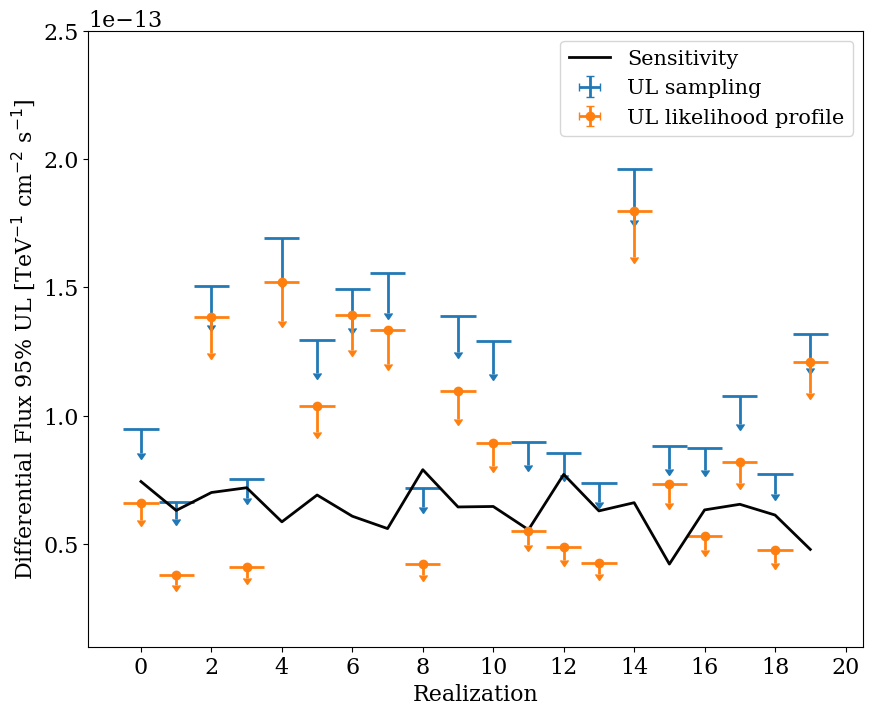

In [12]:
from matplotlib.ticker import MaxNLocator
fig, ax = plt.subplots(figsize=(10,8))

arrowfraction=0.1
alpha=0.99
lw=2
x=np.arange(Nrun)
with quantity_support():
    ax.errorbar(x,uls_uniform_zero,xerr=np.ones(Nrun)*0.5,yerr=arrowfraction*uls_uniform_zero, alpha=alpha,
                label="UL sampling", uplims=True,fmt='None', lw=lw,ls='None')
    ax.errorbar(x,uls_profile_zero,xerr=np.ones(Nrun)*0.5,yerr=arrowfraction*uls_profile_zero, alpha=alpha,
                 marker='o',color='tab:orange',ecolor='tab:orange', label="UL likelihood profile", uplims=True, lw=lw,ls='None')

#    ax.scatter(x,uls_profile_zero, alpha=0.3,color='blue', marker='x', label="LL profile zero")    
    ax.plot(x,sensitivity_zero,color='k',lw=lw,alpha=alpha, label="Sensitivity")
    

#    ax.scatter(x,uls_log_uniform, alpha=0.5, color='green', label="Log-uniform prior")
#ax.set_yscale('log')
ax.xaxis.set_major_locator(MaxNLocator(nbins=11))
ax.set_xlabel('Realization')
ax.set_ylabel(r'Differential Flux 95% UL [TeV$^{-1}$ cm$^{-2}$ s$^{-1}$]')
ax.set_ylim(1e-14,2.5e-13)
plt.legend()
#plt.title(f"UL_comparison_zero_gammapy_v{gammapy.__version__}")

plt.savefig(f"UL_comparison_zero_gammapy_v{gammapy.__version__}.pdf")
